## The TX-TL Toolbox in BioCRNpyler

### A recreation of the original MATLAB TxTl Toolbox, as seen in [Singhal et al. 2020](https://www.biorxiv.org/content/10.1101/2020.08.05.237990v1)

This tutorial shows how to use the EnergyTxTlExtract Mixture with a parameter file derived from the paper above. This Mixture is a simplification of the models used in the original toolbox. Notable changes include:
1. Using only a single nucleotide species NTPs (instead of GTP, ATP, UTP, and CTP)
2. A slightly different NTP regeneration Mechanism which explicitly incorporates the amount of fuel, 3PGA, put into the extract and metabolic leak of the extract.
3. Degredation of RNA bound to ribosomes (which releases the ribosome).
4. A modification of the Energy consumption reactions for Transcription and Translation so that there is only a single binding reaction.

### The CRN displayed below shows the energy utilization process model

Species(N = 8) = {
    metabolite[amino_acids] (@ 30000.0),  
    found_key=(mech=initial concentration, partid=None, name=amino_acids).
    search_key=(mech=initial concentration, partid=, name=amino_acids).

    metabolite[Fuel_3PGA] (@ 30000.0),  
    found_key=(mech=initial concentration, partid=None, name=Fuel_3PGA).
    search_key=(mech=initial concentration, partid=, name=Fuel_3PGA).

    metabolite[NTPs] (@ 5000.0),  
    found_key=(mech=initial concentration, partid=None, name=NTPs).
    search_key=(mech=initial concentration, partid=, name=NTPs).

    metabolite[ATP] (@ 5000.0),  
    found_key=(mech=initial concentration, partid=None, name=ATP).
    search_key=(mech=initial concentration, partid=, name=ATP).

    protein[Ribo] (@ 10.0),  
    found_key=(mech=initial concentration, partid=None, name=Ribo).
    search_key=(mech=initial concentration, partid=, name=Ribo).

    protein[RNAP] (@ 0.5),  
    found_key=(mech=initial concentration, partid=None, name=RNAP).
    searc

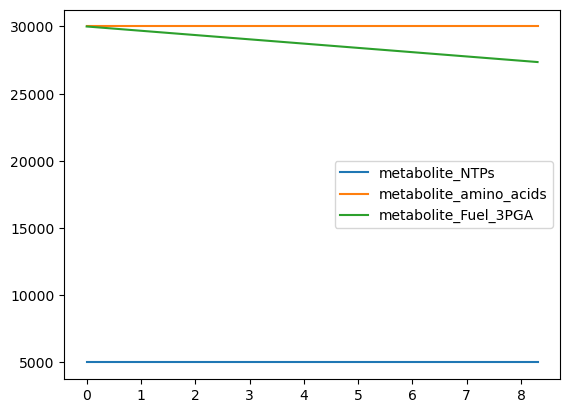

In [1]:
from biocrnpyler.mixtures import EnergyTxTlExtract
#A = DNAassembly("A", promoter = "P", rbs = "rbs")
E = EnergyTxTlExtract(parameter_file = 'mixtures/extract_parameters.tsv')
CRN = E.compile_crn()
print(CRN.pretty_print())
try:
    import numpy as np
    maxtime = 30000
    timepoints = np.arange(0, maxtime, 100)
    R = CRN.simulate_with_bioscrape_via_sbml(timepoints)
    if R is not None:
        import pylab as plt
        plt.plot(timepoints, R[str(E.ntps.get_species())], label = E.ntps.get_species())
        plt.plot(timepoints, R[str(E.amino_acids.get_species())], label = E.amino_acids.get_species())
        plt.plot(timepoints, R[str(E.fuel.get_species())], label = E.fuel.get_species())
        plt.xticks(np.arange(0, maxtime, 3600), [str(i) for i in range(0, int(np.ceil(maxtime/3600)))])
        plt.legend()
except ModuleNotFoundError:
    print('please install the plotting libraries: pip install biocrnpyler[all]')

#### Adding a DNA assembly 
This will produce protein expression, but for a limited time. The

Species(N = 15) = {
    metabolite[amino_acids] (@ 30000.0),  
    found_key=(mech=initial concentration, partid=None, name=amino_acids).
    search_key=(mech=initial concentration, partid=, name=amino_acids).

    metabolite[Fuel_3PGA] (@ 30000.0),  
    found_key=(mech=initial concentration, partid=None, name=Fuel_3PGA).
    search_key=(mech=initial concentration, partid=, name=Fuel_3PGA).

    metabolite[NTPs] (@ 5000.0),  
    found_key=(mech=initial concentration, partid=None, name=NTPs).
    search_key=(mech=initial concentration, partid=, name=NTPs).

    metabolite[ATP] (@ 5000.0),  
    found_key=(mech=initial concentration, partid=None, name=ATP).
    search_key=(mech=initial concentration, partid=, name=ATP).

    protein[Ribo] (@ 10.0),  
    found_key=(mech=initial concentration, partid=None, name=Ribo).
    search_key=(mech=initial concentration, partid=, name=Ribo).

    protein[RNAP] (@ 0.5),  
    found_key=(mech=initial concentration, partid=None, name=RNAP).
    sear

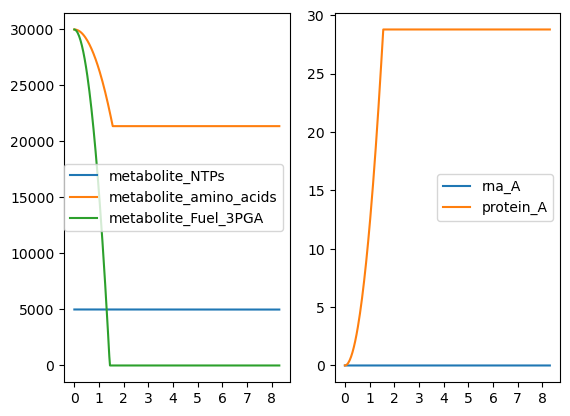

In [2]:
from biocrnpyler.components import DNAassembly
from biocrnpyler.mixtures import EnergyTxTlExtract
import numpy as np
import pylab as plt


A = DNAassembly("A", promoter = "P",
                rbs = "rbs")
E = EnergyTxTlExtract(components = [A],
                      parameter_file = 'mixtures/extract_parameters.tsv')

CRN = E.compile_crn()

print(CRN.pretty_print())
try:
    maxtime = 30000
    timepoints = np.arange(0, maxtime, 100)
    # set mrna degradation resource 
    x0_dict = {E.rnaase.get_species(): 0, A.dna: 1e-6}
    R = CRN.simulate_with_bioscrape_via_sbml(timepoints,
                                             initial_condition_dict=x0_dict)
    if R is not None:
        plt.subplot(121)
        plt.plot(timepoints, R[str(E.ntps.get_species())], label = E.ntps.get_species())
        plt.plot(timepoints, R[str(E.amino_acids.get_species())], label = E.amino_acids.get_species())
        plt.plot(timepoints, R[str(E.fuel.get_species())], label = E.fuel.get_species())
        plt.xticks(np.arange(0, maxtime, 3600), [str(i) for i in range(0, int(np.ceil(maxtime/3600)))])
        plt.legend()
        
        plt.subplot(122)
        plt.plot(timepoints, R[str(A.transcript)], label = A.transcript)
        plt.plot(timepoints, R[str(A.protein)], label = A.protein)
        plt.xticks(np.arange(0, maxtime, 3600), [str(i) for i in range(0, int(np.ceil(maxtime/3600)))])
        plt.legend()
except ModuleNotFoundError:
    print('please install the plotting libraries: pip install biocrnpyler[all]')

In [3]:
type(A.dna)

biocrnpyler.core.species.Species

In [4]:
CRN.species

[dna_A,
 protein_RNAP,
 rna_A,
 metabolite_NTPs,
 complex_dna_A_protein_RNAP_,
 metabolite_ATP,
 metabolite_amino_acids,
 protein_Ribo,
 protein_A,
 complex_protein_Ribo_rna_A_,
 protein_RNAase,
 metabolite_Fuel_3PGA,
 metabolite_ADP,
 complex_complex_protein_Ribo_rna_A__protein_RNAase_,
 complex_protein_RNAase_rna_A_]

In [5]:
# End